In [1]:
from google.colab import files
uploaded = files.upload()

Saving telco.csv to telco.csv


In [4]:
import pandas as pd


In [6]:
df = pd.read_csv('telco.csv' )

In [7]:
df.shape

(7043, 50)

In [8]:
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [9]:
df.isnull().sum()

,0
Customer ID,0
Gender,0
Age,0
Under 30,0
Senior Citizen,0
Married,0
Dependents,0
Number of Dependents,0
Country,0
State,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [11]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [12]:
df[df['Internet Type'].isnull()]['Internet Service'].value_counts()

,count
Internet Service,
No,1526


In [13]:
df['Internet Type'] = df['Internet Type'].fillna('No Internet')

1. Customer Status Distribution

In [14]:
df['Customer Status'].value_counts()

,count
Customer Status,
Stayed,4720
Churned,1869
Joined,454


2. Churn Label Distribution

In [15]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


3. Contract Distribution

In [16]:
df['Contract'].value_counts()

,count
Contract,
Month-to-Month,3610
Two Year,1883
One Year,1550


4. Internet Service Distribution

In [17]:
df['Internet Service'].value_counts()

,count
Internet Service,
Yes,5517
No,1526


5. Satisfaction Score Distribution

In [18]:
df['Satisfaction Score'].value_counts().sort_index()

,count
Satisfaction Score,
1,922
2,518
3,2665
4,1789
5,1149


In [19]:
# Offer
df['Offer'] = df['Offer'].fillna('No Offer')

# Internet Type
df['Internet Type'] = df['Internet Type'].fillna('No Internet')

In [20]:
df.isnull().sum()

,0
Customer ID,0
Gender,0
Age,0
Under 30,0
Senior Citizen,0
Married,0
Dependents,0
Number of Dependents,0
Country,0
State,0


In [21]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[0,30,45,60,100],
    labels=['18-30','31-45','46-60','60+']
)

In [22]:
df['Tenure Group'] = pd.cut(
    df['Tenure in Months'],
    bins=[0,12,24,48,72],
    labels=['0-1 Year','1-2 Years','2-4 Years','4-6 Years']
)

In [23]:
drop_cols = [
    'Customer ID',
    'Latitude',
    'Longitude',
    'Zip Code'
]

df = df.drop(columns=drop_cols)

In [24]:
df.to_csv('cleaned_telco_customer_churn.csv', index=False)

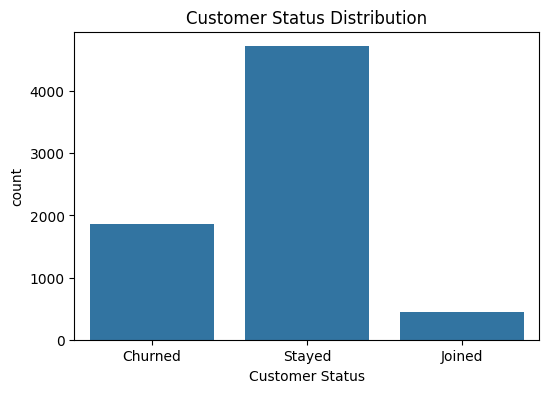

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Customer Status')
plt.title('Customer Status Distribution')
plt.show()

In [26]:
churn_rate = (df['Churn Label'] == 'Yes').mean() * 100
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 26.54%


Analysis 1: Contract Type vs Churn

In [28]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn Label'],
    normalize='index'
) * 100

contract_churn

Churn Label,No,Yes
Contract,,
Month-to-Month,54.155125,45.844875
One Year,89.290323,10.709677
Two Year,97.450876,2.549124


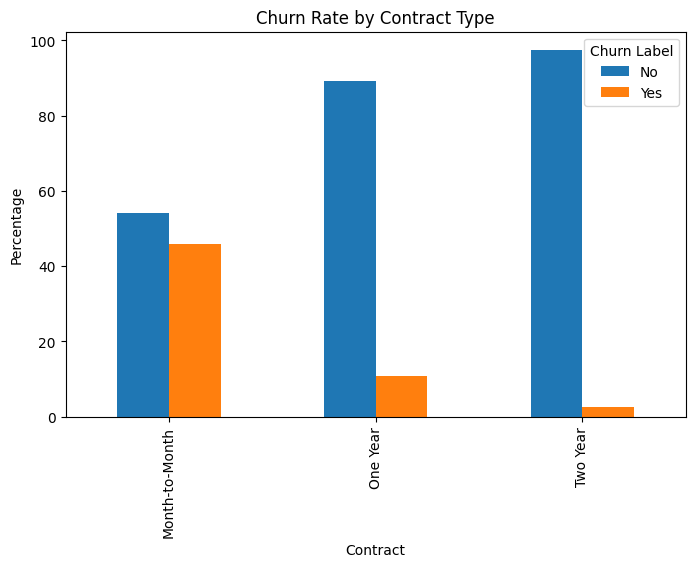

In [29]:
contract_churn.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Churn Rate by Contract Type')
plt.ylabel('Percentage')
plt.show()

Analysis 2: Revenue impact

In [31]:
df.groupby('Customer Status')['Total Revenue'].sum()

,Total Revenue
Customer Status,
Churned,3684459.82
Joined,54279.75
Stayed,17632392.12


In [32]:
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-Month,54.155125,45.844875
One Year,89.290323,10.709677
Two Year,97.450876,2.549124


1. Churn by Tenure Group


In [36]:
tenure_churn = pd.crosstab(
    df['Tenure Group'],
    df['Churn Label'],
    normalize='index'
) * 100

tenure_churn

Churn Label,No,Yes
Tenure Group,,
0-1 Year,52.561757,47.438243
1-2 Years,71.289062,28.710938
2-4 Years,79.611041,20.388959
4-6 Years,90.486824,9.513176


2. Churn by Payment Method

In [35]:
payment_churn = pd.crosstab(
    df['Payment Method'],
    df['Churn Label'],
    normalize='index'
) * 100

payment_churn.sort_values('Yes', ascending=False)

Churn Label,No,Yes
Payment Method,,
Mailed Check,63.116883,36.883117
Bank Withdrawal,66.001535,33.998465
Credit Card,85.522008,14.477992


3. Churn by Internet Type

In [37]:
internet_churn = pd.crosstab(
    df['Internet Type'],
    df['Churn Label'],
    normalize='index'
) * 100

internet_churn.sort_values('Yes', ascending=False)

Churn Label,No,Yes
Internet Type,,
Fiber Optic,59.275124,40.724876
Cable,74.337349,25.662651
DSL,81.416465,18.583535
No Internet,92.595020,7.404980


4. Revenue by Contract

In [38]:
df.groupby('Contract')['Total Revenue'].sum().sort_values(ascending=False)

,Total Revenue
Contract,
Two Year,9036849.16
One Year,6171794.31
Month-to-Month,6162488.22


5. Top Churn Reasons

In [39]:
df[df['Churn Label']=='Yes']['Churn Category'].value_counts()

,count
Churn Category,
Competitor,841
Attitude,314
Dissatisfaction,303
Price,211
Other,200


In [40]:
df[df['Churn Label']=='Yes']['Churn Reason'].value_counts().head(10)

,count
Churn Reason,
Competitor had better devices,313
Competitor made better offer,311
Attitude of support person,220
Don't know,130
Competitor offered more data,117
Competitor offered higher download speeds,100
Attitude of service provider,94
Price too high,78
Product dissatisfaction,77


In [42]:
tenure_churn

Churn Label,No,Yes
Tenure Group,,
0-1 Year,52.561757,47.438243
1-2 Years,71.289062,28.710938
2-4 Years,79.611041,20.388959
4-6 Years,90.486824,9.513176


In [43]:

payment_churn.sort_values('Yes', ascending=False)


Churn Label,No,Yes
Payment Method,,
Mailed Check,63.116883,36.883117
Bank Withdrawal,66.001535,33.998465
Credit Card,85.522008,14.477992


In [44]:
internet_churn.sort_values('Yes', ascending=False)


Churn Label,No,Yes
Internet Type,,
Fiber Optic,59.275124,40.724876
Cable,74.337349,25.662651
DSL,81.416465,18.583535
No Internet,92.595020,7.404980


In [45]:
df.groupby('Contract')['Total Revenue'].sum().sort_values(ascending=False)


,Total Revenue
Contract,
Two Year,9036849.16
One Year,6171794.31
Month-to-Month,6162488.22


In [46]:
df[df['Churn Label']=='Yes']['Churn Category'].value_counts()


,count
Churn Category,
Competitor,841
Attitude,314
Dissatisfaction,303
Price,211
Other,200


In [47]:
df[df['Churn Label']=='Yes']['Churn Reason'].value_counts().head(10)

,count
Churn Reason,
Competitor had better devices,313
Competitor made better offer,311
Attitude of support person,220
Don't know,130
Competitor offered more data,117
Competitor offered higher download speeds,100
Attitude of service provider,94
Price too high,78
Product dissatisfaction,77


In [48]:
from google.colab import files
files.download('cleaned_telco_customer_churn.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>